In [4]:
import numpy as np
import matplotlib.pyplot as plt
import ot

In [5]:
# Problem size
n1 = 25
n2 = 50

# Generate random data
np.random.seed(0)
a = ot.utils.unif(n1)  # Weights of points in the source domain
b = ot.utils.unif(n2)  # Weights of points in the target domain

x1 = np.random.randn(n1, 2)  # Source points
x1 /= np.sqrt(np.sum(x1 ** 2, axis=1, keepdims=True)) / 2       # Normalize to lie on the unit circle

x2 = np.random.randn(n2, 2)  # Target points
x2 /= np.sqrt(np.sum(x2 ** 2, axis=1, keepdims=True)) / 4       # Normalize to lie on the unit circle

### Entropic OT with Sinkhorn algorithm

In [6]:
# Solve the Sinkhorn problem (just add reg parameter value)
sol = ot.solve_sample(x1, x2, a, b, reg=0.1)

# get the OT plan and loss
P_sink = sol.plan
loss_sink = sol.value                   # objective value of the Sinkhorn problem (incl. entropy)
loss_sink_linear = sol.value_linear     # np.sum(P_sink * C) linear part of loss

print(P_sink)
print(loss_sink)
print(loss_sink_linear)

[[2.91162764e-076 5.73574128e-099 1.66177948e-023 ... 5.22434293e-005
  6.11652531e-048 1.11393338e-108]
 [1.79645239e-050 1.74902637e-157 1.00048315e-002 ... 2.12643203e-054
  2.67695431e-015 5.16198773e-117]
 [2.30862483e-075 9.57451120e-039 1.67975985e-056 ... 3.20860958e-014
  8.77642863e-067 5.40172081e-073]
 ...
 [2.28267819e-017 4.42836375e-023 9.31276589e-104 ... 5.68573490e-167
  2.57978948e-046 1.49331352e-002]
 [4.57245314e-005 8.80339681e-122 1.32845039e-047 ... 1.05228456e-168
  7.09493589e-005 1.04587381e-049]
 [3.72314086e-006 6.64798072e-068 1.41227822e-084 ... 1.05436821e-186
  4.82095543e-026 2.83038583e-017]]
5.565579779584747
5.313176741728203


/home/ansible/miniconda3/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:902: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


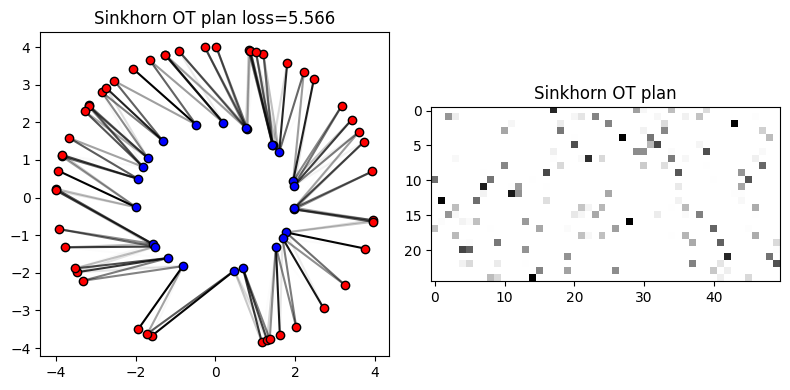

In [7]:
plt.figure(figsize=(8, 4))

# Left plot: 2D samples and transport plan
plt.subplot(1, 2, 1)
# You can use ot.plot.plot2D_samples_mat if available, otherwise draw lines manually
for i in range(n1):
    for j in range(n2):
        if P_sink[i, j] > 1e-4:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_sink[i, j] / np.max(P_sink)), zorder=0)

plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title(f'Sinkhorn OT plan loss={loss_sink:.3f}')

# Right plot: Transport plan matrix
plt.subplot(1, 2, 2)
plt.imshow(P_sink, cmap='Greys')
plt.title('Sinkhorn OT plan')

plt.tight_layout()
plt.show()

The Sinkhorn algorithm solves the Entropic Regularized OT problem. The regularization strength can be controlled with the `reg` parameter. The Sinkhorn algorithm can be faster than the exact OT solver for large regularization strength but the solution is only an approximation of the exact OT problem and the OT plan is not sparse.

### Quadratic Regularized OT

In [9]:
# Use quadratic regularization
P_quad = ot.solve_sample(x1, x2, a, b, reg=3, reg_type="L2").plan

loss_quad = ot.solve_sample(x1, x2, a, b, reg=3, reg_type="L2").value

print(P_quad)
print(loss_quad)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.0093099  ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.02000303]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
5.34246260779674


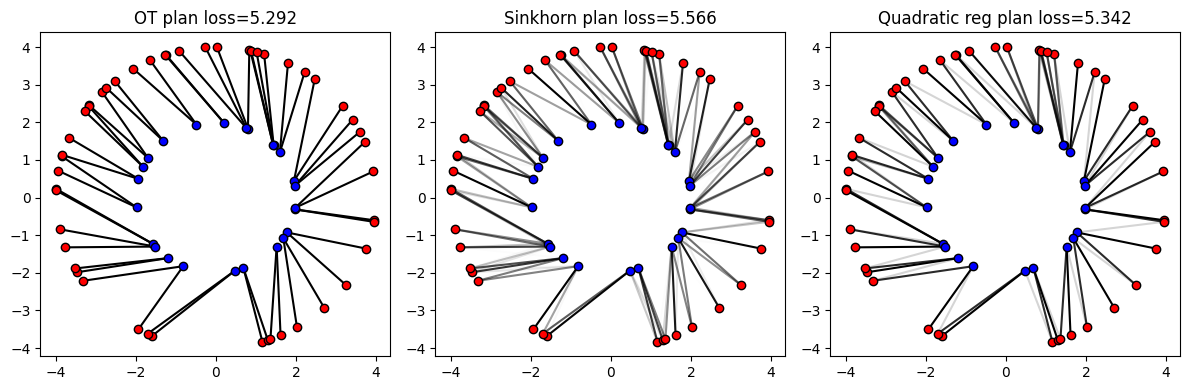

In [10]:
# Compute exact OT for comparison
sol_exact = ot.solve_sample(x1, x2, a, b)
P_exact = sol_exact.plan
loss_exact = sol_exact.value

plt.figure(figsize=(12, 4))

# Left plot: Exact OT plan
plt.subplot(1, 3, 1)
for i in range(n1):
    for j in range(n2):
        if P_exact[i, j] > 1e-4:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_exact[i, j] / np.max(P_exact)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title(f'OT plan loss={loss_exact:.3f}')

# Middle plot: Sinkhorn OT plan
plt.subplot(1, 3, 2)
for i in range(n1):
    for j in range(n2):
        if P_sink[i, j] > 1e-4:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_sink[i, j] / np.max(P_sink)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title(f'Sinkhorn plan loss={loss_sink:.3f}')

# Right plot: Quadratic Regularized OT plan
plt.subplot(1, 3, 3)
for i in range(n1):
    for j in range(n2):
        if P_quad[i, j] > 1e-4:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_quad[i, j] / np.max(P_quad)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title(f'Quadratic reg plan loss={loss_quad:.3f}')

plt.tight_layout()
plt.show()

### Solve the Regularized OT problem with user-defined regularization

In [11]:
# Define a custom regularization function
def f(G):
    return 0.5 * np.sum(G**2)

def df(G):
    return G

P_reg = ot.solve_sample(x1, x2, a, b, reg=3, reg_type=(f, df)).plan

print(P_reg)

[[5.93491032e-11 5.93491032e-11 5.93491032e-11 ... 5.93491032e-11
  5.93491032e-11 5.93491032e-11]
 [5.93491032e-11 5.93491032e-11 9.34122533e-03 ... 5.93491032e-11
  5.93491032e-11 5.93491032e-11]
 [5.93491032e-11 5.93491032e-11 5.93491032e-11 ... 5.93491032e-11
  5.93491032e-11 5.93491032e-11]
 ...
 [5.93491032e-11 5.93491032e-11 5.93491032e-11 ... 5.93491032e-11
  5.93491032e-11 1.99999986e-02]
 [5.93491032e-11 5.93491032e-11 5.93491032e-11 ... 5.93491032e-11
  5.93491032e-11 5.93491032e-11]
 [5.93491032e-11 5.93491032e-11 5.93491032e-11 ... 5.93491032e-11
  5.93491032e-11 5.93491032e-11]]


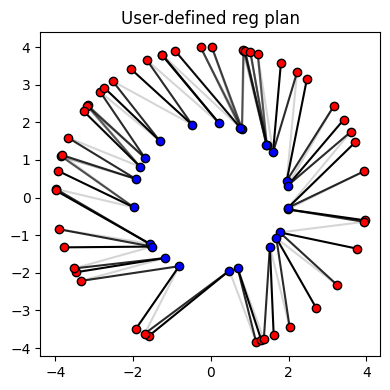

In [12]:
plt.figure(figsize=(4, 4))

for i in range(n1):
    for j in range(n2):
        if P_reg[i, j] > 1e-4:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_reg[i, j] / np.max(P_reg)), zorder=0)

plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('User-defined reg plan')

plt.tight_layout()
plt.show()